In [5]:
import tensorflow as tf
from tensorflow.keras import layers,models
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical



In [6]:
fashion_mnist = tf.keras.datasets.fashion_mnist

In [7]:
(x_train,y_train),(x_test,y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
print(x_test.shape)

(10000, 28, 28)


In [9]:
# checking the uniques classes in the dataset. IT IS BEHIND THE ANN JUST TO UNDERSTAND THE DATA
import numpy as np

# Get unique values and their counts
unique_classes, counts = np.unique(y_train, return_counts=True)

print("Unique classes:", unique_classes)
print("Counts per class:", counts)
print("\nClass distribution:")
for cls, count in zip(unique_classes, counts):
    print(f"Class {cls}: {count} samples ({count/len(y_train)*100:.1f}%)")

Unique classes: [0 1 2 3 4 5 6 7 8 9]
Counts per class: [6000 6000 6000 6000 6000 6000 6000 6000 6000 6000]

Class distribution:
Class 0: 6000 samples (10.0%)
Class 1: 6000 samples (10.0%)
Class 2: 6000 samples (10.0%)
Class 3: 6000 samples (10.0%)
Class 4: 6000 samples (10.0%)
Class 5: 6000 samples (10.0%)
Class 6: 6000 samples (10.0%)
Class 7: 6000 samples (10.0%)
Class 8: 6000 samples (10.0%)
Class 9: 6000 samples (10.0%)


<function matplotlib.pyplot.show(close=None, block=None)>

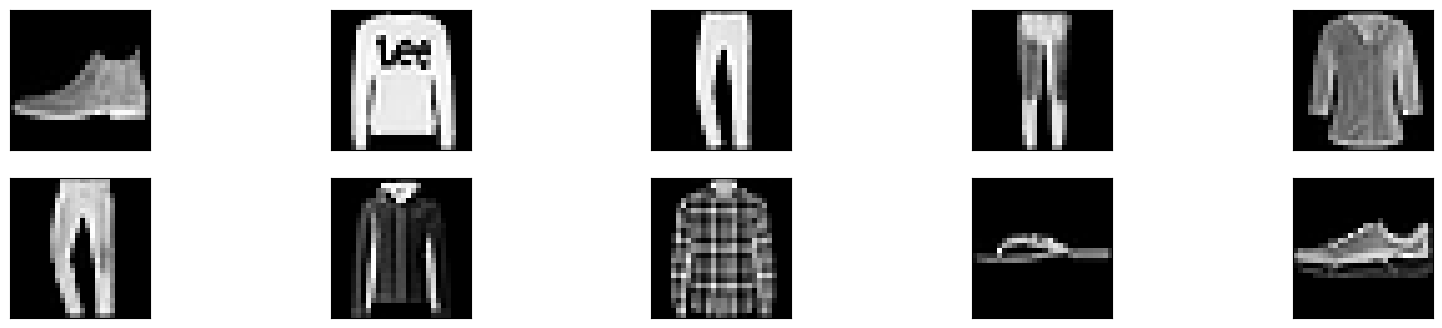

In [16]:
# number of images to display
n = 10
# create a figure to display the images
plt.figure(figsize=(20,4))

# loop through the first n images
for i in range(n):
  # create a subplot within the figure
  ax = plt.subplot(2,n//2,i+1)     # 2 rows count, n columns count , i+1 position number in the figure

  # Display the original image
  plt.imshow(x_test[i].reshape(28,28))

  # Set colormap to grayscale
  plt.gray()

  # Hide x-axis and y-axos labels
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

plt.show


In [18]:
# now flattening the images which is essetial which converts the 2d images into 1d means flatten them
x_train = x_train.reshape(60000,784)
x_test = x_test.reshape(10000,784)

In [20]:
# now we have to normalize the data means it becomes better for model training
# Best practice for Fashion-MNIST:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
# we divide the data by 255 as there are total 256 color range from 0 to 255

In [21]:
# processing the Target Variable
classes = 10  # as we find them above that we have 10 uniques classes in the data
y_train = to_categorical(y_train,classes)
y_test = to_categorical(y_test,classes)
# convert the labels to one hot encoding

In [23]:
# for  checking classes not related to AI
# Convert one-hot back to integers for checking
y_train_integers = np.argmax(y_train, axis=1)  # Reverse one-hot encoding
unique_classes = np.unique(y_train_integers)
print("Unique classes:", unique_classes)

Unique classes: [0 1 2 3 4 5 6 7 8 9]


**Setting up HyperParamters for the model**

In [24]:

input_size = 784
batch_size = 200
hidden1 = 400
hidden2 = 200
hidden3 = 50
classes = 10
epochs = 10

**Building the Model**

In [28]:
# we will create the sequestial model which will allow us to build a neural network layer by layer
model = Sequential()


model.add(Dense(hidden1,input_dim = input_size,activation='relu'))
model.add(Dense(hidden2,activation='relu'))
model.add(Dense(hidden3,activation='relu'))

model.add(Dense(classes,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
### Compilation ###
# compile the model by specifying the loss function , optimizer, and evaluation metrics
model.compile(loss='categorical_crossentropy',metrics=['accuracy'],optimizer='adam')
# display the summary of the model architecture , showing the layers and parameter counts

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 400)            │       314,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        80,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │        10,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,760 (1.54 MB)

 Trainable params: 404,760 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

**Training the Model**

In [34]:
from time import time
tic = time()

model.fit(x_train , y_train,batch_size=500 , epochs = epochs , verbose = 1)

toc = time()

print(f"Model training took {toc - tic} secs")

Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8918 - loss: 0.3013
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8924 - loss: 0.3015
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8926 - loss: 0.3016
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8930 - loss: 0.3007
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8941 - loss: 0.2973
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8920 - loss: 0.2999
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8923 - loss: 0.2983
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8929 - loss: 0.3012
Epoch 9/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8939 - loss: 0.2933
Epoch 10/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8955 - loss: 0.2941
Model training took 6.2952470779418945 secs


**Testing the Model**

In [35]:
from sklearn.metrics import accuracy_score

y_pred_probs = model.predict(x_test,verbose = 0)
y_pred = np.argmax(y_pred_probs ,axis = 1)

test_accuracy = accuracy_score(y_pred,y_test)
print(f"Accuracy Score {test_accuracy}")

Accuracy Score 0.8513


In [39]:
# Testing the random range data
mask = range(20,51)
x_mask_test = x_test[mask]
actual_y_mask_labels = y_test[mask]

y_pred_mask_labels = model.predict(x_mask_test)
y_pred_mask_valid = np.argmax(y_pred_mask_labels ,axis = 1)
test_accuracy = accuracy_score(y_pred,y_test)
print(f"Accuracy Score {test_accuracy}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Accuracy Score 0.8513


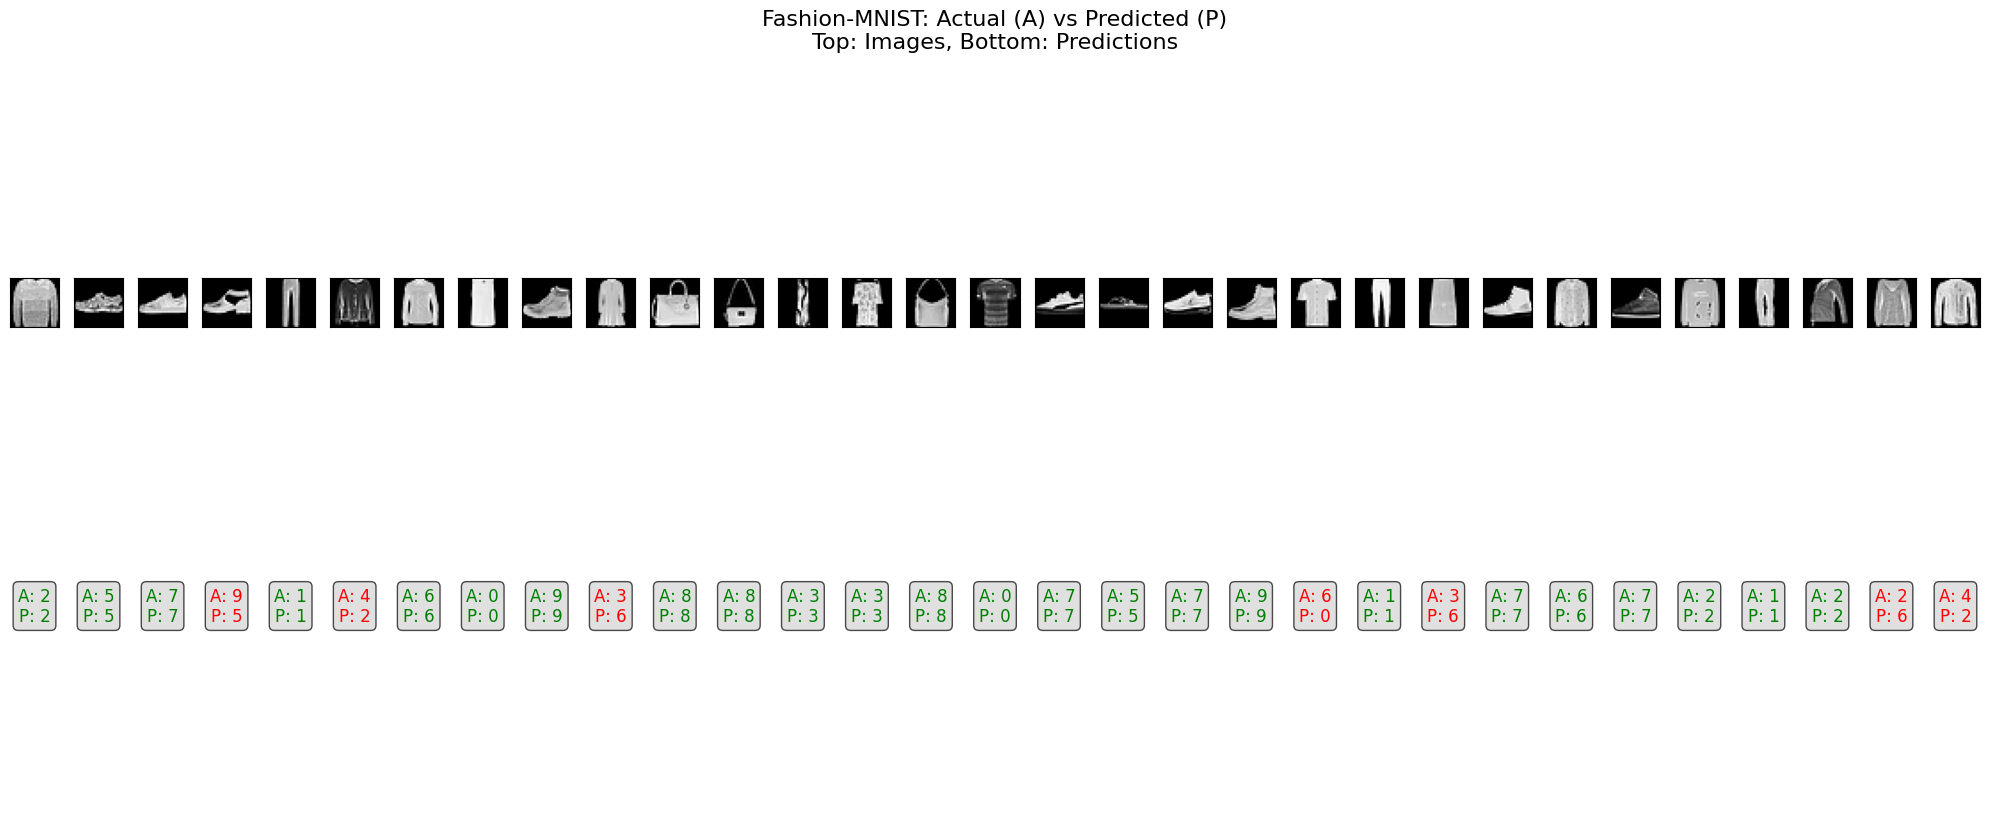

In [40]:
# display the images with predicted and actual data
n = len(x_mask_test)
plt.figure(figsize=(20,8))
for i in range(n):
 ax = plt.subplot(2,n,i+1)
 if x_mask_test[i].shape == (28, 28):
        plt.imshow(x_mask_test[i], cmap='gray')
 else:
        plt.imshow(x_mask_test[i].reshape(28, 28), cmap='gray')
 plt.gray()
 ax.get_xaxis().set_visible(False)
 ax.get_yaxis().set_visible(False)


# ----- ROW 2: Display Actual vs Predicted -----
 ax = plt.subplot(2, n, i + 1 + n)  # FIXED: i+1+n (not i+1+2*n)
    # Get actual label (already integer 0-9)
 actual_digit = actual_y_mask_labels[i]  # NO np.argmax() needed!
 if isinstance(actual_digit, np.ndarray) and actual_digit.size > 1:
        actual_digit = np.argmax(actual_digit)  # It's one-hot array
 else:
        actual_digit = int(actual_digit)



    # Get predicted label (already integer 0-9 from your argmax)
 predicted_digit = int(y_pred_mask_valid[i]) # NO np.argmax() needed!
    # Color coding: green if correct, red if wrong
 color = 'green' if actual_digit == predicted_digit else 'red'
    # Display both in one subplot
 plt.text(0.5, 0.5, f"A: {actual_digit}\nP: {predicted_digit}",
             fontsize=12, ha='center', va='center', color=color,
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.7))
 plt.axis('off')


plt.suptitle('Fashion-MNIST: Actual (A) vs Predicted (P)\nTop: Images, Bottom: Predictions',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
